[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module3_Files/notebooks/Autoencoders_for_Images.ipynb)

# Autoencoders for Images
------------------------------------
**Dr. Dave Wanik - University of Connecticut**

An **autoencoder** squishes an image down into a tiny code ('latent vector') and then rebuilds the original from just that code. If it can rebuild the image from, say, 32 numbers, we've effectively learned a compression of the data - and that little code turns out to be useful for all sorts of things.

Here we'll build one simple dense autoencoder to see the idea cleanly: **784 pixels -> 32-number code -> 784 pixels back**. Once the mechanics click, head to **`What_Autoencoders_Can_Actually_Do`** for the payoff (anomaly detection, features, denoising, and clustering).

In [ ]:
# load the mnist data
# we don't need the y labels for this notebook
from keras.datasets import mnist
import numpy as np
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


In [ ]:
# recall that each number is stored as a 28* 28 array
print(x_train[0].shape)
# take a look for yourself
x_train


(28, 28)


array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
# let's actually SEE one - x_train is still 28x28 here (before we flatten it)
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap="gray")
plt.title(f"a hand-drawn {y_train[0]}")
plt.axis("off"); plt.show()

In [ ]:
# flatten each 28x28 image into a single row of 784 numbers
x_train = x_train.astype('float32') / 255.   # scale pixels to 0-1
x_test  = x_test.astype('float32')  / 255.
x_train = x_train.reshape(-1, 28*28)          # -1 = "numpy, figure out how many rows"
x_test  = x_test.reshape(-1, 28*28)
print(x_train.shape)   # (60000, 784)
print(x_test.shape)    # (10000, 784)

(60000, 784)
(10000, 784)


# Define the Model (simple autoencoder)
Our model is going to read in the flattened image. Then the encoded layer is going to squish it down into a 32 long vector. Then the dense layer is going to try to reconstruct the original 784 long vector from that 32 long vector.

The best part of this thing is the middle (where the input image is squished into a 32 long vector - tiny!)

We can imagine that our model will do OK - but that a little bit of information may be lost along the way (try making 784 things out of 32 things... this is tricky!)

---
**Heads up - we're switching to the Functional API here.** So far we've stacked layers with the *Sequential* API (`model.add(...)`, like building a cake). Below you'll see a different style: we call each layer on the one before it - `Dense(...)(input_img)` - and then wrap it up with `Model(inputs, outputs)`. Why bother? Because in a minute we want to pull the **encoder** out on its own (input -> the 32-number code), and the Functional API lets us name the input and the middle layer and snap a sub-model out of them. That's the one place the extra syntax earns its keep.

In [ ]:
from keras.layers import Input, Dense
from keras.models import Model

# this is the size of our encoded representations
encoding_dim = 32  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats (elements)

# this is our input placeholder
input_img = Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = Dense(encoding_dim, activation='relu')(input_img)
# "decoded" is the lossy reconstruction of the input
decoded = Dense(784, activation='sigmoid')(encoded)

# this model maps an input to its reconstruction
autoencoder = Model(input_img, decoded)
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 784)]             0         
                                                                 
 dense (Dense)               (None, 32)                25120     
                                                                 
 dense_1 (Dense)             (None, 784)               25872     
                                                                 
Total params: 50,992
Trainable params: 50,992
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# to get this model to fit, we will use per-pixel binary cross-entropy loss
# because this is a grayscale image
# link: https://stats.stackexchange.com/questions/349096/cross-entropy-for-comparing-images
# for a color image, just use loss='mse'

# there is an implicit assumption along the lines of "black means class 0, white means class 1" and then some grey pixel value of 0.1 means the pixel very likely belongs to the black class
autoencoder.compile(optimizer='Adam', loss='binary_crossentropy')

# Fit the model (simple autoencoder)

In [ ]:
# here we go! (early stopping keeps the best epoch, just like our ConvNets)
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = autoencoder.fit(x_train, x_train, # notice how X and Y are both x_train
                epochs=100,       # ceiling - early stopping decides when to quit
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test),
                callbacks=[early_stop])

Epoch 1/50
235/235 [==============================] - 7s 24ms/step - loss: 0.2752 - val_loss: 0.1897
Epoch 2/50
235/235 [==============================] - 6s 24ms/step - loss: 0.1711 - val_loss: 0.1536
Epoch 3/50
235/235 [==============================] - 5s 23ms/step - loss: 0.1442 - val_loss: 0.1340
Epoch 4/50
235/235 [==============================] - 3s 12ms/step - loss: 0.1289 - val_loss: 0.1219
Epoch 5/50
235/235 [==============================] - 3s 12ms/step - loss: 0.1189 - val_loss: 0.1138
Epoch 6/50
235/235 [==============================] - 3s 13ms/step - loss: 0.1119 - val_loss: 0.1082
Epoch 7/50
235/235 [==============================] - 3s 13ms/step - loss: 0.1067 - val_loss: 0.1033
Epoch 8/50
235/235 [==============================] - 3s 12ms/step - loss: 0.1029 - val_loss: 0.1001
Epoch 9/50
235/235 [==============================] - 3s 12ms/step - loss: 0.1000 - val_loss: 0.0975
Epoch 10/50
235/235 [==============================] - 3s 12ms/step - loss: 0.0978 - val_lo

In [ ]:
# how did training go? plot the loss curves
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],     label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epoch'); plt.ylabel('loss (binary crossentropy)'); plt.legend()
plt.title('Autoencoder training'); plt.show()

# Specify Individual Encoder and Decoder Models (simple autoencoder)
Note that we are not fitting these models - we will just call our `autoencoder` and use this to make our predictions.

In [ ]:
# this model maps an input to its encoded representation
encoder = Model(input_img, encoded)
# create a placeholder for an encoded (32-dimensional) input
encoded_input = Input(shape=(encoding_dim,))
# retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# create the decoder model
decoder = Model(encoded_input, decoder_layer(encoded_input))

# Make a Prediction (simple autoencoder)
Let's use our model to predict the encoded and decoded images on x_test. Note how we are not using y ANYWHERE here.

In [ ]:
# encode and decode some digits
# note that we take them from the *test* set
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

In [ ]:
# see what you did
print(encoded_imgs.shape) # wow. our 10K shapes have been stored as 32 long vectors
# and we also can also reconstruct them!
print(decoded_imgs.shape) # right back to 784 elements!

(10000, 32)
(10000, 784)


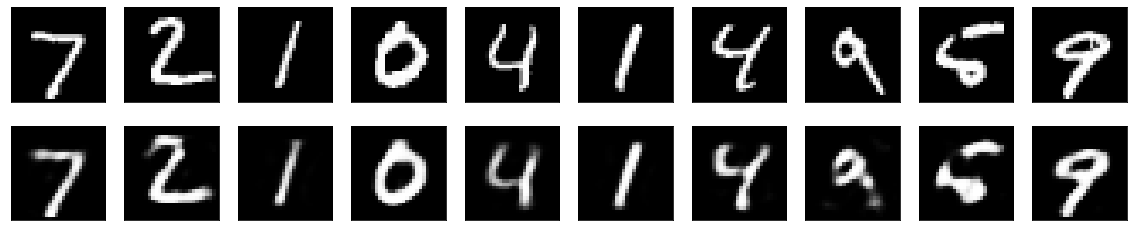

In [ ]:
# let's see how we did
# use Matplotlib
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original (with its true digit)
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title(str(y_test[i]), fontsize=9)
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle('TOP: original digit   |   BOTTOM: autoencoder reconstruction', fontsize=14)
plt.show()

The figures are a little grainy, but that's OK! It is still pretty impressive that a 32 long representation can create a 784 long representation. Let's see what the encoded images look like for this (we will reshape from a 32 long vector into a 4*8 array for convenience).

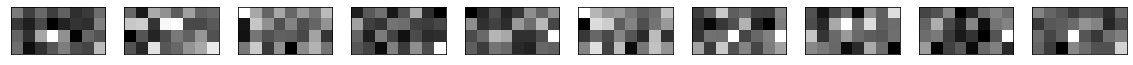

In [ ]:
n = 10
plt.figure(figsize=(20, 8))
for i in range(n):
    ax = plt.subplot(1, n, i+1) # the website is off - don't forget i+1!
    plt.imshow(encoded_imgs[i].reshape(4, 8))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle('The compressed 32-number code for each digit (shown as 4x8)', fontsize=14)
plt.show()

# it is amazing that these gibberish pictures can be inputted into a decoder
# which turns them into pretty pictures

## That's the whole idea

We squished each 784-pixel image into a **32-number code** and rebuilt it - a learned compression, no labels involved. The reconstructions are a little grainy (32 numbers is a *tight* squeeze), but the shape is clearly there.

**So what?** That's the fun part - open **`What_Autoencoders_Can_Actually_Do`** to use this same idea for:
- **Anomaly detection** (big reconstruction error = outlier)
- **Features** (train a classifier on the 32-number code)
- **Denoising** (map dirty images to clean ones)
- **Clustering** (the codes group themselves by digit)

## Appendix: the same autoencoder, the Sequential way

Prefer the **Sequential** "stack the layers" style you've used all along? You can build the exact same autoencoder that way. The one extra step is pulling the encoder and decoder back out afterward - and we do that by **reusing the trained layers** (no retraining).

In [ ]:
from keras import Sequential

seq_ae = Sequential([
    Input(shape=(784,)),
    Dense(32,  activation="relu",    name="code"),   # encoder: squish to 32
    Dense(784, activation="sigmoid", name="rebuild"),# decoder: back to 784
])
seq_ae.compile(optimizer="adam", loss="binary_crossentropy")
seq_ae.summary()

seq_ae.fit(x_train, x_train,
           epochs=100, batch_size=256, shuffle=True,
           validation_data=(x_test, x_test),
           callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)])

To get the **encoder** and **decoder** on their own, we don't rebuild anything - we just reuse the already-trained layers inside a tiny new `Sequential`:

In [ ]:
# reuse the trained layers - same weights, just repackaged
seq_encoder = Sequential([Input(shape=(784,)), seq_ae.layers[0]])   # input -> 32-number code
seq_decoder = Sequential([Input(shape=(32,)),  seq_ae.layers[1]])   # code  -> reconstruction

codes = seq_encoder.predict(x_test[:5], verbose=0)
print("encoded shape:", codes.shape)                          # (5, 32)
print("decoded shape:", seq_decoder.predict(codes, verbose=0).shape)  # (5, 784)

Same model, same 32-number code - just written differently. **Functional** (up top) makes the encoder/decoder split a one-liner because you name the input and the middle layer directly. **Sequential** is a touch more familiar, but you pull the sub-models out by hand afterward. Use whichever reads better to you.

## Appendix: a *convolutional* autoencoder

Everything above **flattened** each image into 784 numbers and used **dense** layers - which quietly throws away the fact that a pixel's neighbors matter. For images, a **convolutional** autoencoder usually does better:

- the **encoder** shrinks the image with `Conv2D` + strides (exactly like a ConvNet),
- the **decoder** mirrors it with `Conv2DTranspose` to *grow* the image back to full size.

Same idea - squish, then rebuild - but the layers respect the 2D structure and **share weights** (one small filter slid across the whole image), so you get sharper reconstructions with *far* fewer parameters.

> Conv layers are heavier than dense ones, so this appendix trains faster on a **T4 GPU** - but it's still fine on CPU (a few minutes on MNIST).

In [ ]:
from keras.layers import Conv2D, Conv2DTranspose

# conv layers want the 2D image shape back (not the flat 784) - add a channel dim
Xc_train = x_train.reshape(-1, 28, 28, 1)   # x_train is already scaled to 0-1 from above
Xc_test  = x_test.reshape(-1, 28, 28, 1)

inp = Input(shape=(28, 28, 1))
# encoder: shrink the image with strided convs   28 -> 14 -> 7
e = Conv2D(16, 3, strides=2, padding='same', activation='relu')(inp)   # 14x14x16
e = Conv2D(8,  3, strides=2, padding='same', activation='relu')(e)     # 7x7x8  <- the code (a little image stack)
# decoder: grow it back with transposed convs    7 -> 14 -> 28
d = Conv2DTranspose(8,  3, strides=2, padding='same', activation='relu')(e)   # 14x14x8
d = Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu')(d)   # 28x28x16
out = Conv2D(1, 3, padding='same', activation='sigmoid')(d)                   # 28x28x1  (back to one image)

conv_ae = Model(inp, out)
conv_ae.compile(optimizer='adam', loss='binary_crossentropy')
conv_ae.summary()   # notice how FEW params this has vs the dense version

In [ ]:
# same fit recipe as before - early stopping, capture history for the loss curve
conv_hist = conv_ae.fit(Xc_train, Xc_train,
                        epochs=100, batch_size=256, shuffle=True,
                        validation_data=(Xc_test, Xc_test),
                        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)])

plt.plot(conv_hist.history['loss'],     label='train loss')
plt.plot(conv_hist.history['val_loss'], label='validation loss')
plt.xlabel('epoch'); plt.ylabel('loss (binary crossentropy)'); plt.legend()
plt.title('Convolutional autoencoder training'); plt.show()

In [ ]:
# how do the reconstructions look? (should be crisper than the 32-number dense version)
recon = conv_ae.predict(Xc_test[:10], verbose=0)
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i+1)
    plt.imshow(Xc_test[i].reshape(28, 28), cmap='gray'); plt.title(str(y_test[i]), fontsize=9)
    ax.get_xaxis().set_visible(False); ax.get_yaxis().set_visible(False)
    ax = plt.subplot(2, n, i+n+1)
    plt.imshow(recon[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False); ax.get_yaxis().set_visible(False)
plt.suptitle('Conv autoencoder  -  TOP: original   |   BOTTOM: reconstruction', fontsize=14)
plt.show()

Sharper reconstructions, **fewer parameters** - because convolutions reuse the same small filters across the whole image instead of learning a separate weight for every pixel.

The trade-off is the **code**: here it isn't a neat 32-number vector, it's a small `7x7x8` stack of feature maps (392 numbers that still carry a spatial layout). So:

- want a **tiny flat code** for the classifier / clustering tricks? the **dense** version up top is easier to work with.
- want the **best image reconstruction**? go **convolutional**.
- want both? real systems often run conv layers down to a `Flatten` + small `Dense` code, then `Dense` + `Reshape` back up - the best of each.